# Big Data Processing Algorithm
### Project: Word Count Analysis

In [23]:
!pip install pandas matplotlib nltk wordcloud

In [24]:
import os
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from itertools import islice
from nltk.corpus import stopwords
from nltk.util import ngrams
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [25]:
# Step 1: Load Data (Text Files for Word Count)

folder_path = r"D:/SDS/WMASDS/Big Data/Data/text_files"  # Folder containing text files
all_words = []

In [26]:
for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
            text = f.read().lower()
            text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
            all_words.extend(text.split())

print(f"Total words processed: {len(all_words)}")

Total words processed: 15


In [27]:
# Step 2: Word Count (MapReduce Style)

word_counts = Counter(all_words)
print("\nTop 10 most frequent words:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")


Top 10 most frequent words:
bigdata: 5
analysis: 4
data: 2
science: 2
i: 1
love: 1


In [28]:
# Step 3: N-Gram Analysis (Bigrams)

bigrams = zip(all_words, all_words[1:])
bigram_counts = Counter(bigrams)
print("\nTop 10 Bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(f"{bg}: {count}")


Top 10 Bigrams:
('bigdata', 'analysis'): 4
('analysis', 'bigdata'): 4
('data', 'science'): 2
('i', 'love'): 1
('love', 'data'): 1
('science', 'data'): 1
('science', 'bigdata'): 1


In [29]:
# Step 4: Convert Word Count to DataFrame for Analysis

df_word_count = pd.DataFrame(word_counts.items(), columns=["Word", "Count"])
df_word_count = df_word_count.sort_values(by="Count", ascending=False)
print("\nWord count DataFrame head:\n", df_word_count.head())


Word count DataFrame head:
        Word  Count
4   bigdata      5
5  analysis      4
2      data      2
3   science      2
0         i      1



Total unique words: 6


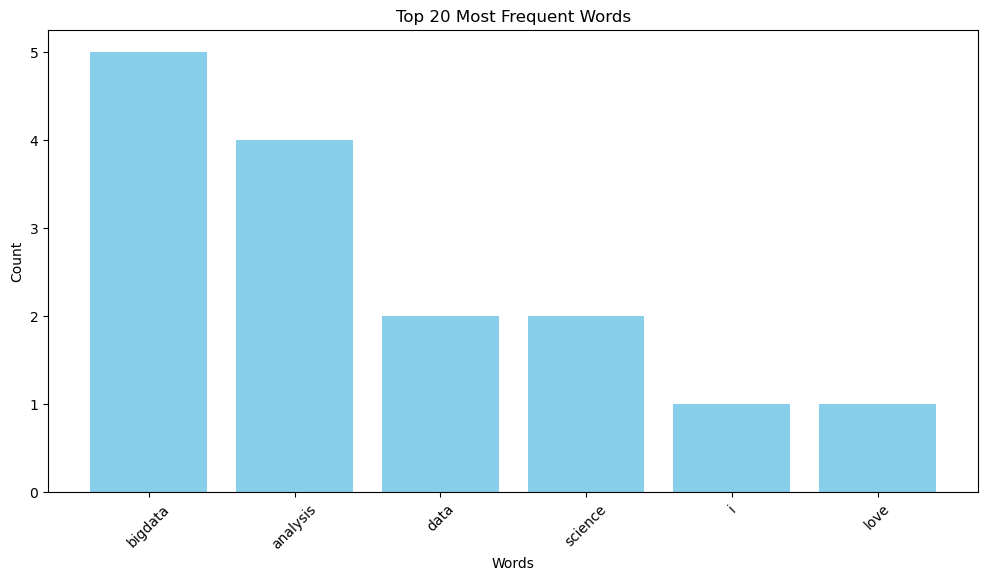

In [30]:
#  Step 5: Simple Exploratory Data Analysis

# Total unique words
print("\nTotal unique words:", df_word_count.shape[0])

# Top 20 words visualization
top20 = df_word_count.head(20)
plt.figure(figsize=(12,6))
plt.bar(top20['Word'], top20['Count'], color='skyblue')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [31]:
# Function to generate ngrams
def generate_ngrams(words_list, n):
    return list(ngrams(words_list, n))

bigrams = generate_ngrams(all_words, 2)
trigrams = generate_ngrams(all_words, 3)

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

print("\nTop 10 Bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(bg, count)

print("\nTop 10 Trigrams:")
for tg, count in trigram_counts.most_common(10):
    print(tg, count)


Top 10 Bigrams:
('bigdata', 'analysis') 4
('analysis', 'bigdata') 4
('data', 'science') 2
('i', 'love') 1
('love', 'data') 1
('science', 'data') 1
('science', 'bigdata') 1

Top 10 Trigrams:
('bigdata', 'analysis', 'bigdata') 4
('analysis', 'bigdata', 'analysis') 3
('i', 'love', 'data') 1
('love', 'data', 'science') 1
('data', 'science', 'data') 1
('science', 'data', 'science') 1
('data', 'science', 'bigdata') 1
('science', 'bigdata', 'analysis') 1


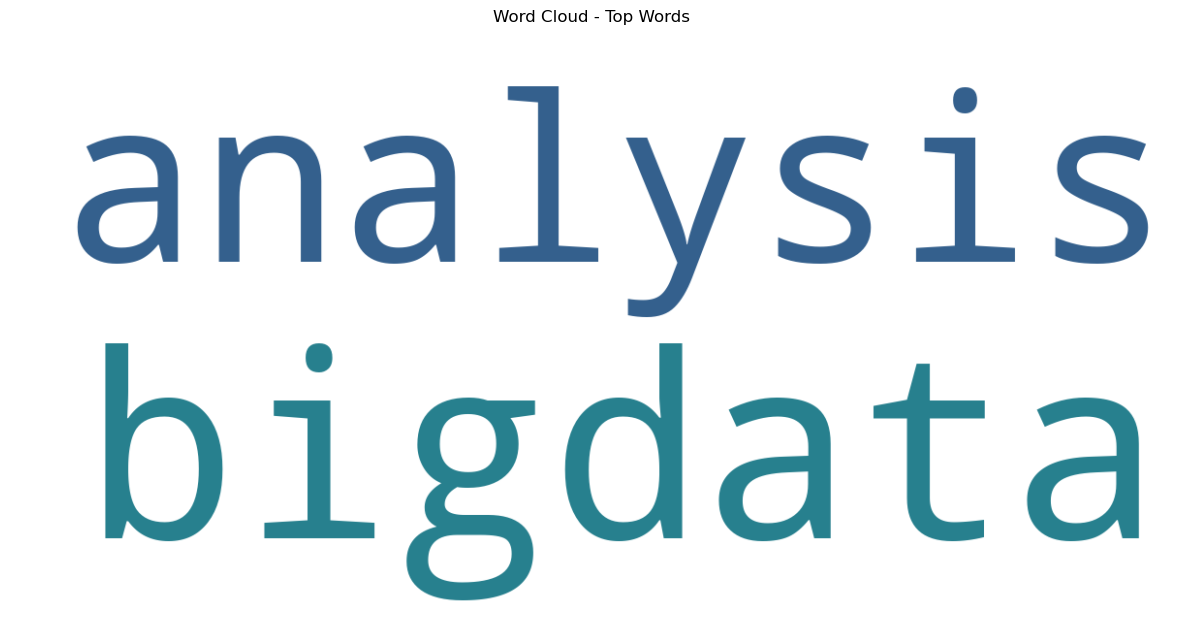

In [32]:
# Step 4: Word Cloud Visualization

wc = WordCloud(width=1200, height=600, background_color='white', max_words=200).generate_from_frequencies(filtered_counts)

plt.figure(figsize=(15,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Top Words")
plt.show()

In [33]:
# Step 7: Save Word Count Result

output_path = "output/word_count.csv"
os.makedirs("output", exist_ok=True)
df_word_count.to_csv(output_path, index=False)
print(f"\nWord count results saved to {output_path}")


Word count results saved to output/word_count.csv
